# Report — MVTec AD Anomaly Detection

Questo notebook raccoglie i risultati del rilevamento di anomalie tramite un autoencoder convoluzionale denoising (denoising conv-AE), addestrato separatamente per ciascuna categoria di prodotto del dataset MVTec AD con una loss combinata SSIM + MSE, e ne confronta le prestazioni (AUROC a livello di immagine e di pixel) tra le 15 categorie e tra due varianti di ablazione. Per il design completo vedere `docs/design.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))

from anomaly_ae.ablation import ABLATION_CATEGORIES
from anomaly_ae.report import ablation_comparison_dataframe, load_metrics, metrics_to_dataframe
from data_classes.mvtec_dataset import CATEGORIES

OUTPUT_ROOT = Path.cwd().parent / "outputs"

## 1. Confronto tra le 15 categorie

> **Stato attuale**: allenate e valutate solo 5 delle 15 categorie (`bottle`, `carpet`,
> `leather`, `screw`, `transistor`). Questa sezione richiede il training completo delle
> altre 10 categorie prima di poter essere eseguita senza errori.

In [2]:
main_metrics = load_metrics(OUTPUT_ROOT, CATEGORIES)
main_df = metrics_to_dataframe(main_metrics)
main_df[["image_level_auroc", "pixel_level_auroc"]].plot.bar(figsize=(12, 4))
main_df

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\UNIVERSITA\\MAGISTRALE\\ML\\PROGETTO\\outputs\\cable\\metrics.json'

### Ispezione qualitativa

Griglie `originale | ricostruzione | mappa di anomalia | maschera reale` prodotte da
`python test.py` per alcune categorie rappresentative: una texture ripetitiva
(`carpet`), un oggetto rigido ben posizionato (`bottle`) e un oggetto piccolo e
difficile (`screw`).

bottle: sample_0.png


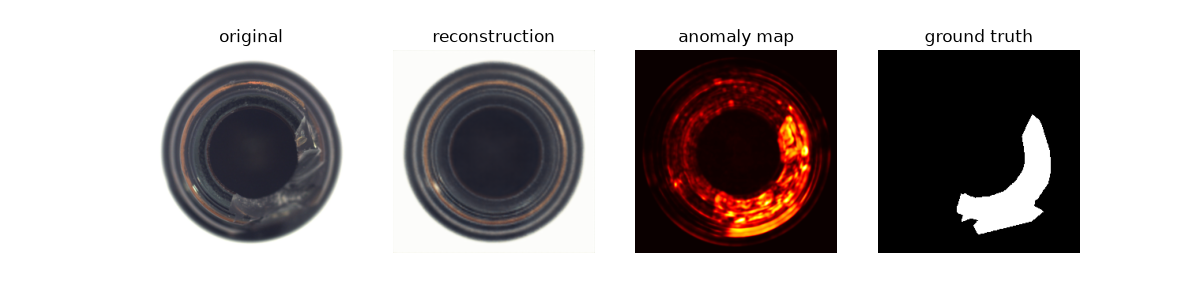

bottle: sample_10.png


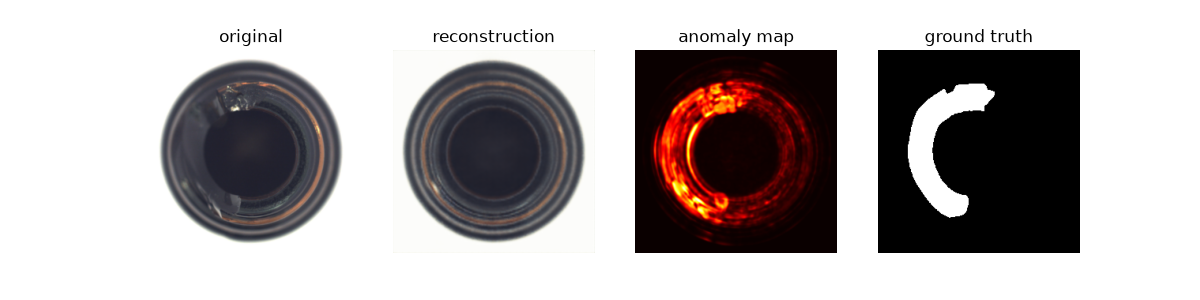

carpet: sample_0.png


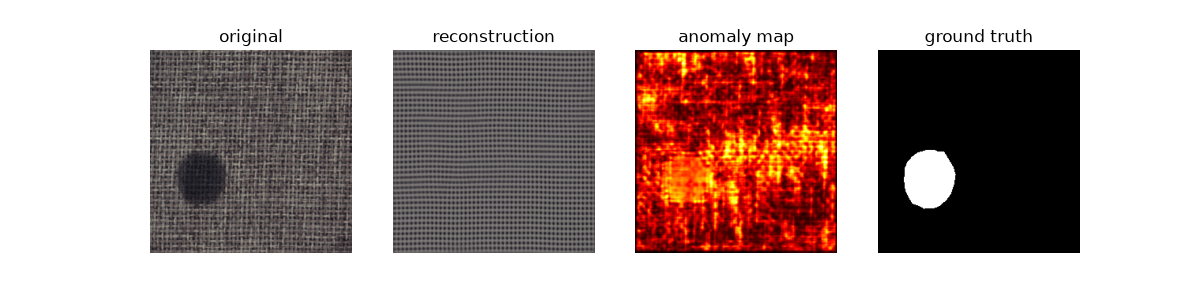

carpet: sample_14.png


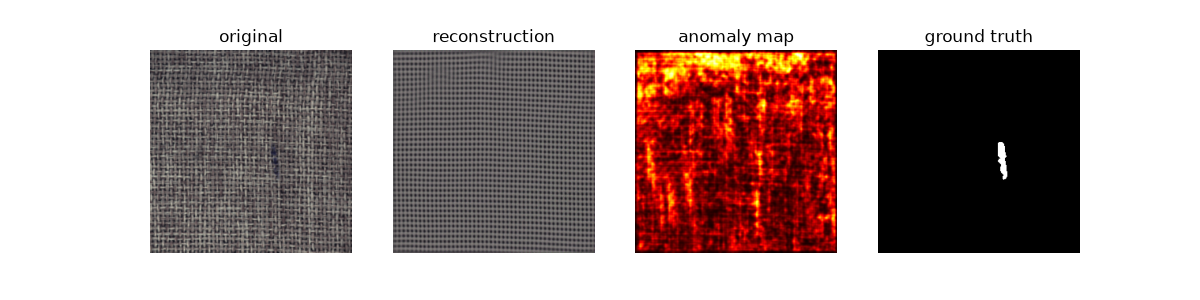

screw: sample_0.png


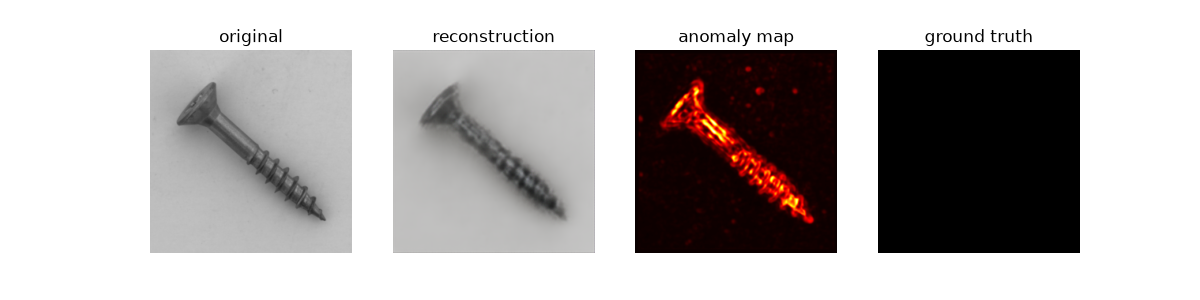

screw: sample_100.png


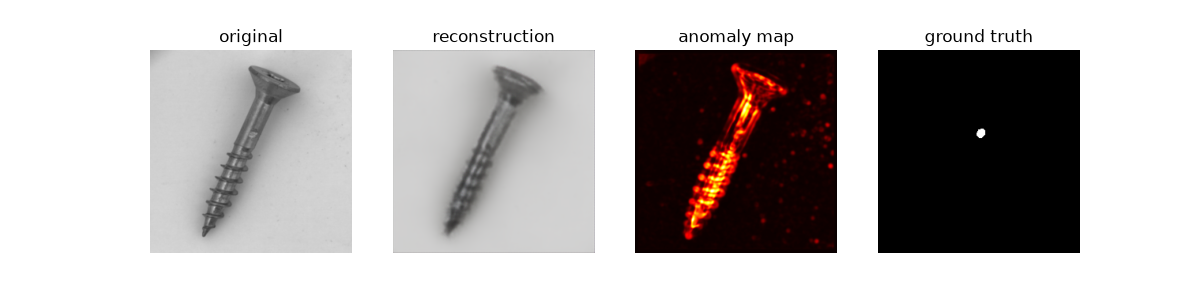

In [3]:
for category in ["bottle", "carpet", "screw"]:
    sample_paths = sorted((OUTPUT_ROOT / category).glob("sample_*.png"))
    for path in sample_paths[:2]:
        print(f"{category}: {path.name}")
        display(Image(filename=str(path)))

### Curve di training

Loss di training e di validation per epoca (`history.csv`), utile per verificare
convergenza ed effetto dell'early stopping sulle stesse categorie.

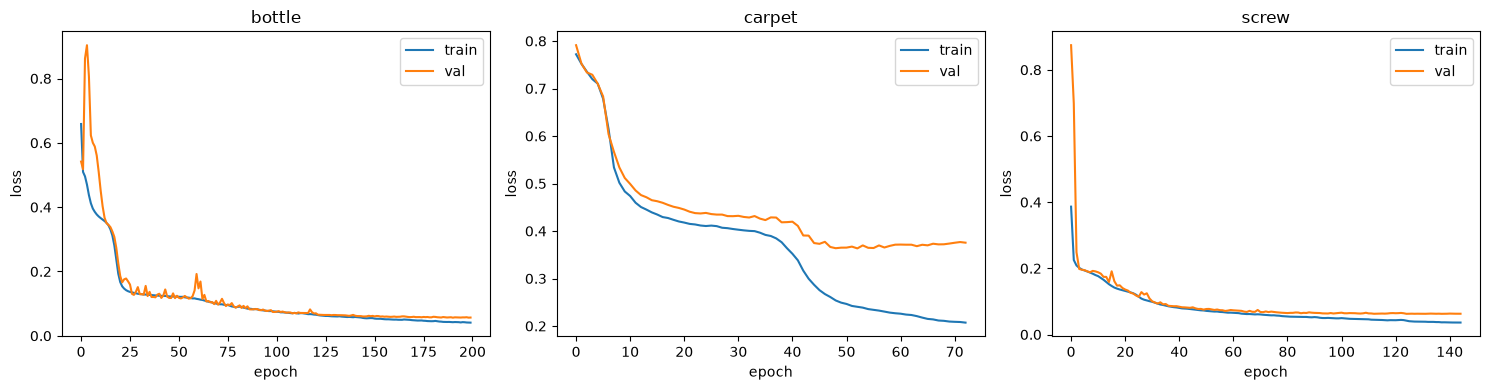

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, category in zip(axes, ["bottle", "carpet", "screw"]):
    history = pd.read_csv(OUTPUT_ROOT / category / "history.csv")
    ax.plot(history["epoch"], history["train_loss"], label="train")
    ax.plot(history["epoch"], history["val_loss"], label="val")
    ax.set_title(category)
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()
plt.tight_layout()

### Decisione concreta alla soglia

L'AUROC è una metrica continua, indipendente dalla soglia. Usando gli score
per-immagine e la soglia (95° percentile degli score sul train set `good`) ora
salvati in `metrics.json`, si può mostrare la decisione binaria normale/anomalo
effettivamente presa dal sistema: di seguito l'accuratezza per categoria a quella
soglia.

In [5]:
rows = []
for category, m in main_metrics.items():
    scores = m["image_scores"]
    labels = m["image_labels"]
    threshold = m["threshold"]
    predictions = [1 if s > threshold else 0 for s in scores]
    correct = sum(p == l for p, l in zip(predictions, labels))
    rows.append({"category": category, "accuracy_at_threshold": correct / len(labels)})
pd.DataFrame(rows).set_index("category")

NameError: name 'main_metrics' is not defined

## 2. Ablation — loss SSIM+MSE vs solo MSE

In [6]:
# Caricato direttamente dalle 5 categorie di ablation, indipendentemente dal
# training delle 15 categorie complete (sezione 1), cosi' le sezioni 2 e 3
# sono eseguibili anche prima che quel training sia terminato.
main_subset = load_metrics(OUTPUT_ROOT, ABLATION_CATEGORIES)

In [7]:
mse_only_metrics = load_metrics(OUTPUT_ROOT / "ablation_mse_only", ABLATION_CATEGORIES)
loss_ablation_df = ablation_comparison_dataframe(main_subset, mse_only_metrics, "mse_only")
loss_ablation_df[["image_auroc_main", "image_auroc_mse_only"]].plot.bar(figsize=(10, 4))
loss_ablation_df

FileNotFoundError: [Errno 2] No such file or directory: 'D:\\UNIVERSITA\\MAGISTRALE\\ML\\PROGETTO\\outputs\\ablation_mse_only\\carpet\\metrics.json'

## 3. Ablation — denoising vs senza rumore

,image_auroc_main,image_auroc_no_denoising,pixel_auroc_main,pixel_auroc_no_denoising
category,,,,
carpet,0.576645,0.570225,0.742922,0.742646
leather,0.863111,0.847486,0.788052,0.786020
bottle,0.862698,0.865873,0.924075,0.912153
screw,0.418323,0.382455,0.966144,0.969921
transistor,0.616667,0.590417,0.882873,0.886281


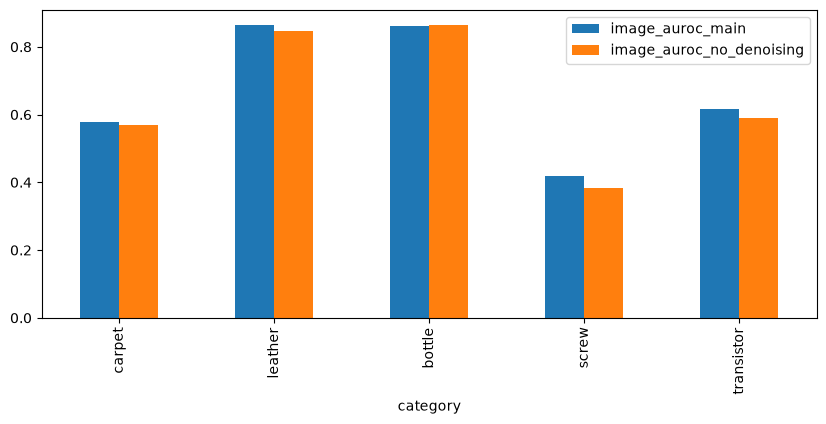

In [8]:
no_denoising_metrics = load_metrics(OUTPUT_ROOT / "ablation_no_denoising", ABLATION_CATEGORIES)
denoising_ablation_df = ablation_comparison_dataframe(main_subset, no_denoising_metrics, "no_denoising")
denoising_ablation_df[["image_auroc_main", "image_auroc_no_denoising"]].plot.bar(figsize=(10, 4))
denoising_ablation_df

## 4. Discussione finale

### Ablation denoising vs senza rumore (sezione 3, dati reali su 5 categorie)

| Categoria | Δ Image AUROC (rumore − no rumore) | Δ Pixel AUROC |
|---|---|---|
| bottle | −0.003 | +0.012 |
| carpet | +0.006 | +0.000 |
| leather | +0.016 | +0.002 |
| screw | +0.036 | −0.004 |
| transistor | +0.026 | −0.003 |
| **media** | **+0.016** | **+0.001** |

- Il denoising in training migliora l'AUROC image-level in 4 categorie su 5 (unica
  eccezione `bottle`, di poco), con un guadagno medio piccolo ma consistente nella
  direzione attesa — coerente con l'ipotesi di design (previene la scorciatoia della
  quasi-identità che ricostruirebbe fedelmente anche i difetti).
- Sul pixel-level l'effetto è sostanzialmente nullo (+0.001 in media, segno variabile
  tra categorie): la qualità della localizzazione dipende soprattutto dalla loss SSIM,
  non dal rumore in training.

### Un limite osservato, indipendente dall'ablation

`screw` (e in misura minore `carpet`) hanno AUROC image-level vicino o **sotto il
livello del caso** (0.42 e 0.58), nonostante un pixel-level AUROC eccellente per screw
(0.97). Causa identificata: a differenza di quanto assunto in `docs/design.md`, `screw`
non ha una posa realmente fissa tra le immagini (la vite compare ruotata/traslata), e
il bottleneck da 100 numeri non riesce a ricostruire fedelmente la filettatura fine,
producendo un errore di ricostruzione diffuso lungo tutto il bordo — alto sia su viti
sane sia difettose. Il **massimo** della mappa di anomalia, usato come score
image-level, non distingue questo errore diffuso "normale" da un vero difetto
puntiforme.

Sono stati testati tre approcci di calibrazione per isolare l'eccesso realmente
anomalo: una baseline media calcolata sul train, un filtro passa-alto gaussiano, e
un'erosione morfologica (min-pooling, per sfruttare la differenza di forma tra bordi
sottili e macchie di difetto più larghe). Il primo e il terzo hanno dato benefici
concreti su `bottle` e `transistor` (fino a +0.10/+0.13 di AUROC image-level), ma
nessuno dei tre ha risolto `screw` in modo soddisfacente, e il filtro passa-alto ha
addirittura peggiorato drasticamente quasi tutte le altre categorie (kernel troppo
grande rispetto a difetti estesi, che venivano soppressi insieme al rumore). Si è
quindi scelto di mantenere lo score originale (massimo della mappa raw), più semplice e
complessivamente più robusto, documentando `screw` come limite noto: una soluzione
reale richiederebbe l'allineamento/registrazione dell'oggetto prima del confronto,
intervento sproporzionato per lo scope di questo progetto.

### Ancora da completare

- **Sezione 1** (confronto sulle 15 categorie): allenate/valutate finora solo 5 delle
  15 categorie. Va completato il training delle restanti 10 prima che sia eseguibile.
- **Sezione 2** (loss SSIM+MSE vs solo MSE): non ancora eseguita su nessuna categoria.
  Serve lanciare `scripts/run.py train --all --ablation mse_only` e la relativa
  `evaluate` sulle 5 categorie di ablation.